In [73]:
# %% =========================================================
# cell 1. imports
# purpose:
# load the libraries needed for file handling, image loading,
# preprocessing, dataset construction, model building,
# training, evaluation, and passive learning
# ============================================================

import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import tifffile as tiff
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

In [74]:
# %% =========================================================
# cell 2. reproducibility and device setup
# purpose:
# fix random seeds and choose the best available device for training
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

Using device: cuda
GPU name: Tesla T4


In [75]:
# %% =========================================================
# cell 3. define dataset paths
# purpose:
# point to the full BBBC006 image folder, label folder, and counts csv
# ============================================================

from pathlib import Path

images_dir = Path("/Users/yeritmaryrodriguezdelgado/Desktop/ASR_Project/DATA/BBBC006_v1_images_z_16")
labels_dir = Path("/Users/yeritmaryrodriguezdelgado/Desktop/ASR_Project/DATA/BBBC006_v1_labels")
counts_csv_path = Path("/Users/yeritmaryrodriguezdelgado/Desktop/ASR_Project/DATA/BBBC006_v1_counts.csv")

print("images_dir:", images_dir)
print("images_dir exists:", images_dir.exists())

print("labels_dir:", labels_dir)
print("labels_dir exists:", labels_dir.exists())

print("counts_csv_path:", counts_csv_path)
print("counts csv exists:", counts_csv_path.exists())

images_dir: /Users/yeritmaryrodriguezdelgado/Desktop/ASR_Project/DATA/BBBC006_v1_images_z_16
images_dir exists: False
labels_dir: /Users/yeritmaryrodriguezdelgado/Desktop/ASR_Project/DATA/BBBC006_v1_labels
labels_dir exists: False
counts_csv_path: /Users/yeritmaryrodriguezdelgado/Desktop/ASR_Project/DATA/BBBC006_v1_counts.csv
counts csv exists: False


In [76]:
# %% =========================================================
# cell 4. inspect folder contents
# purpose:
# preview a few files from the image and label folders to confirm
# that the paths are correct and the files are visible
# ============================================================

print("\nfirst image files:")
image_preview = sorted(list(images_dir.glob("*")))[:10]
for p in image_preview:
    print(p.name)

print("\nfirst label files:")
label_preview = sorted(list(labels_dir.glob("*")))[:10]
for p in label_preview:
    print(p.name)


first image files:

first label files:


In [77]:
# %% =========================================================
# cell 3. define dataset paths for colab
# purpose:
# point to the full BBBC006 image folder, label folder, and counts csv
# stored in Google Drive
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

data_dir = Path("/content/drive/MyDrive/ASR_Project/DATA")

images_dir = data_dir / "BBBC006_v1_images_z_16"
labels_dir = data_dir / "BBBC006_v1_labels"
counts_csv_path = data_dir / "BBBC006_v1_counts.csv"

print("data_dir:", data_dir)
print("images_dir exists:", images_dir.exists())
print("labels_dir exists:", labels_dir.exists())
print("counts csv exists:", counts_csv_path.exists())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
data_dir: /content/drive/MyDrive/ASR_Project/DATA
images_dir exists: True
labels_dir exists: True
counts csv exists: True


In [78]:
# %% =========================================================
# cell 5. load counts csv
# purpose:
# read the nuclei count metadata so it can be attached to samples
# for later evaluation if the names match
# ============================================================

import pandas as pd

counts_df = pd.read_csv(counts_csv_path)

print("counts_df shape:", counts_df.shape)
print(counts_df.head())
print("counts columns:", counts_df.columns.tolist())

counts_df shape: (768, 4)
                                   Image_Count_Nuclei  \
7   mcf-z-stacks-03212011_a01_s1_w197083f74-b742-4...   
18  mcf-z-stacks-03212011_a01_s2_w1a63ef720-8648-4...   
68  mcf-z-stacks-03212011_a02_s1_w1ebe36734-a690-4...   
80  mcf-z-stacks-03212011_a02_s2_w1376ffd1a-e96b-4...   
11  mcf-z-stacks-03212011_a03_s1_w1554aa323-1f38-4...   

    Image_FileName_OrigDAPI Image_Metadata_Site  Image_Metadata_Well  
7                         1                 a01                  NaN  
18                        2                 a01                  NaN  
68                        1                 a02                  NaN  
80                        2                 a02                  NaN  
11                        1                 a03                  NaN  
counts columns: ['Image_Count_Nuclei', 'Image_FileName_OrigDAPI', 'Image_Metadata_Site', 'Image_Metadata_Well']


In [79]:
# %% =========================================================
# cell 6. helper functions for file loading and preprocessing
# purpose:
# define functions to:
# - load raw tif images
# - load label images
# - normalize raw images
# - resize image and mask pairs consistently
# this version avoids trying tifffile on png masks
# ============================================================

def load_tif_image(path):
    path = str(path)
    suffix = Path(path).suffix.lower()

    if suffix in [".tif", ".tiff"]:
        try:
            img = tiff.imread(path)
            return np.asarray(img)
        except Exception as e:
            print(f"tifffile failed for raw image, trying PIL instead: {e}")

    img = Image.open(path)
    img = np.array(img)
    return np.asarray(img)


def load_mask_image(path):
    path = str(path)
    suffix = Path(path).suffix.lower()

    if suffix in [".png", ".jpg", ".jpeg", ".bmp"]:
        mask = Image.open(path)
        mask = np.array(mask)
        return np.asarray(mask)

    if suffix in [".tif", ".tiff"]:
        try:
            mask = tiff.imread(path)
            return np.asarray(mask)
        except Exception as e:
            print(f"tifffile failed for mask, trying PIL instead: {e}")

    mask = Image.open(path)
    mask = np.array(mask)
    return np.asarray(mask)


def percentile_normalize(img, lower=1, upper=99):
    img = img.astype(np.float32)
    lo = np.percentile(img, lower)
    hi = np.percentile(img, upper)

    if hi > lo:
        img = np.clip((img - lo) / (hi - lo), 0, 1)
    else:
        img = np.zeros_like(img, dtype=np.float32)

    return img


def resize_image_and_mask(image, mask, size=(256, 256)):
    image_pil = Image.fromarray((image * 255).astype(np.uint8))
    mask_pil = Image.fromarray(mask.astype(np.uint8))

    image_resized = image_pil.resize(size, Image.BILINEAR)
    mask_resized = mask_pil.resize(size, Image.NEAREST)

    image_resized = np.array(image_resized).astype(np.float32) / 255.0
    mask_resized = np.array(mask_resized).astype(np.float32)
    mask_resized = (mask_resized > 0).astype(np.float32)

    return image_resized, mask_resized

In [80]:
# %% =========================================================
# cell 7. helper functions for matching image, label, and count ids
# purpose:
# define helper functions to extract file stems and create a matching
# rule between label filenames and raw image filenames
# ============================================================

def get_stem(path):
    return Path(path).stem


def build_raw_prefix_from_label_stem(label_stem):
    return "_".join(label_stem.split("_")[:4])


def normalize_counts_columns(df):
    df = df.copy()

    renamed = {}
    for col in df.columns:
        low = col.strip().lower()

        if low in ["image", "image_id", "filename", "file", "name"]:
            renamed[col] = "image_id"
        elif low in ["count", "counts", "manual_count", "cell_count", "nuclei_count"]:
            renamed[col] = "count"

    df = df.rename(columns=renamed)
    return df

In [81]:
# %% =========================================================
# cell 8. build matched sample table
# purpose:
# collect image files and label files, then match them into one
# table with image path, mask path, and optional count metadata
# ============================================================

counts_df = normalize_counts_columns(counts_df)

raw_files = sorted(
    list(images_dir.glob("*.tif")) +
    list(images_dir.glob("*.tiff")) +
    list(images_dir.glob("*.png"))
)

label_files = sorted(
    list(labels_dir.glob("*.tif")) +
    list(labels_dir.glob("*.tiff")) +
    list(labels_dir.glob("*.png"))
)

print("number of raw files found:", len(raw_files))
print("number of label files found:", len(label_files))

raw_map = {get_stem(p): p for p in raw_files}

if "image_id" in counts_df.columns and "count" in counts_df.columns:
    count_map = dict(zip(counts_df["image_id"].astype(str), counts_df["count"]))
else:
    count_map = {}

samples = []

for label_path in label_files:
    label_stem = get_stem(label_path)

    matched_raw_path = None
    matched_raw_stem = None

    if label_stem in raw_map:
        matched_raw_path = raw_map[label_stem]
        matched_raw_stem = label_stem
    else:
        raw_prefix = build_raw_prefix_from_label_stem(label_stem)

        for raw_stem, raw_path in raw_map.items():
            if raw_stem.startswith(raw_prefix):
                matched_raw_path = raw_path
                matched_raw_stem = raw_stem
                break

    if matched_raw_path is None:
        continue

    count_value = count_map.get(matched_raw_stem, np.nan)

    samples.append({
        "image_id": matched_raw_stem,
        "raw_path": str(matched_raw_path),
        "mask_path": str(label_path),
        "count": count_value
    })

samples_df = pd.DataFrame(samples)

print("matched samples shape:", samples_df.shape)
print(samples_df.head())
print("missing counts:", samples_df["count"].isna().sum())

number of raw files found: 1536
number of label files found: 768
matched samples shape: (768, 4)
                                            image_id  \
0  mcf-z-stacks-03212011_a01_s1_w1248254b0-0193-4...   
1  mcf-z-stacks-03212011_a01_s2_w16103c57d-a39e-4...   
2  mcf-z-stacks-03212011_a02_s1_w166fea8cb-8e72-4...   
3  mcf-z-stacks-03212011_a02_s2_w1f0fe13ad-3750-4...   
4  mcf-z-stacks-03212011_a03_s1_w142b8b5c0-97e4-4...   

                                            raw_path  \
0  /content/drive/MyDrive/ASR_Project/DATA/BBBC00...   
1  /content/drive/MyDrive/ASR_Project/DATA/BBBC00...   
2  /content/drive/MyDrive/ASR_Project/DATA/BBBC00...   
3  /content/drive/MyDrive/ASR_Project/DATA/BBBC00...   
4  /content/drive/MyDrive/ASR_Project/DATA/BBBC00...   

                                           mask_path  count  
0  /content/drive/MyDrive/ASR_Project/DATA/BBBC00...    NaN  
1  /content/drive/MyDrive/ASR_Project/DATA/BBBC00...    NaN  
2  /content/drive/MyDrive/ASR_Project/DATA/

In [82]:
# %% =========================================================
# cell 9. clean matched sample table
# purpose:
# keep rows with valid raw and mask paths
# do not drop rows just because count is missing
# ============================================================

samples_df = samples_df.dropna(subset=["raw_path", "mask_path"]).reset_index(drop=True)

print("cleaned samples shape:", samples_df.shape)
print(samples_df.head())
print("missing counts:", samples_df["count"].isna().sum())

cleaned samples shape: (768, 4)
                                            image_id  \
0  mcf-z-stacks-03212011_a01_s1_w1248254b0-0193-4...   
1  mcf-z-stacks-03212011_a01_s2_w16103c57d-a39e-4...   
2  mcf-z-stacks-03212011_a02_s1_w166fea8cb-8e72-4...   
3  mcf-z-stacks-03212011_a02_s2_w1f0fe13ad-3750-4...   
4  mcf-z-stacks-03212011_a03_s1_w142b8b5c0-97e4-4...   

                                            raw_path  \
0  /content/drive/MyDrive/ASR_Project/DATA/BBBC00...   
1  /content/drive/MyDrive/ASR_Project/DATA/BBBC00...   
2  /content/drive/MyDrive/ASR_Project/DATA/BBBC00...   
3  /content/drive/MyDrive/ASR_Project/DATA/BBBC00...   
4  /content/drive/MyDrive/ASR_Project/DATA/BBBC00...   

                                           mask_path  count  
0  /content/drive/MyDrive/ASR_Project/DATA/BBBC00...    NaN  
1  /content/drive/MyDrive/ASR_Project/DATA/BBBC00...    NaN  
2  /content/drive/MyDrive/ASR_Project/DATA/BBBC00...    NaN  
3  /content/drive/MyDrive/ASR_Project/DATA/BBB

In [83]:
# %% =========================================================
# cell 10. inspect one sample
# purpose:
# verify that one raw image and one label load correctly and inspect
# their shapes before creating the dataset class
# ============================================================

print("samples_df shape:", samples_df.shape)

if len(samples_df) == 0:
    print("samples_df is empty. Go back to cell 8 and debug the matching.")
else:
    example_row = samples_df.iloc[0]

    print("\nexample row:")
    print(example_row)

    print("\nraw path exists:", Path(example_row["raw_path"]).exists())
    print("mask path exists:", Path(example_row["mask_path"]).exists())

    example_image = load_tif_image(example_row["raw_path"])
    example_mask = load_mask_image(example_row["mask_path"])

    print("\nraw image shape:", example_image.shape, example_image.dtype)
    print("mask shape:", example_mask.shape, example_mask.dtype)
    print("count value:", example_row["count"])

samples_df shape: (768, 4)

example row:
image_id     mcf-z-stacks-03212011_a01_s1_w1248254b0-0193-4...
raw_path     /content/drive/MyDrive/ASR_Project/DATA/BBBC00...
mask_path    /content/drive/MyDrive/ASR_Project/DATA/BBBC00...
count                                                      NaN
Name: 0, dtype: object

raw path exists: True
mask path exists: True
tifffile failed for raw image, trying PIL instead: <COMPRESSION.LZW: 5> requires the 'imagecodecs' package

raw image shape: (520, 696) uint16
mask shape: (520, 696) uint8
count value: nan


In [84]:
# %% =========================================================
# cell 11. create grouped train, validation, and test splits
# purpose:
# split the dataset by image family/group instead of by individual image
# to reduce leakage between train, validation, and test
# ============================================================

from sklearn.model_selection import GroupShuffleSplit

def make_group_id(image_id):
    parts = image_id.split("_")
    return "_".join(parts[:2]) if len(parts) >= 2 else image_id

samples_df["group_id"] = samples_df["image_id"].apply(make_group_id)

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_idx, temp_idx = next(gss1.split(samples_df, groups=samples_df["group_id"]))

train_df = samples_df.iloc[train_idx].reset_index(drop=True)
temp_df = samples_df.iloc[temp_idx].reset_index(drop=True)

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
val_idx, test_idx = next(gss2.split(temp_df, groups=temp_df["group_id"]))

val_df = temp_df.iloc[val_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_idx].reset_index(drop=True)

print("train size:", len(train_df))
print("val size:", len(val_df))
print("test size:", len(test_df))

train size: 536
val size: 116
test size: 116


In [85]:
# %% =========================================================
# cell. grouped overlap check
# purpose:
# confirm that grouped splitting removed overlap across splits
# ============================================================

train_groups = set(train_df["group_id"])
val_groups = set(val_df["group_id"])
test_groups = set(test_df["group_id"])

print("train ∩ val:", len(train_groups & val_groups))
print("train ∩ test:", len(train_groups & test_groups))
print("val ∩ test:", len(val_groups & test_groups))

train ∩ val: 0
train ∩ test: 0
val ∩ test: 0


In [86]:
# %% =========================================================
# cell 12. dataset class
# purpose:
# define a PyTorch dataset that:
# - loads a raw image and corresponding mask
# - normalizes and resizes them
# - returns image, mask, count, and dataset index
# ============================================================

class NucleiSegmentationDataset(Dataset):
    def __init__(self, dataframe, image_size=(256, 256), return_original_size=False):
        self.samples = dataframe.to_dict("records")
        self.image_size = image_size
        self.return_original_size = return_original_size

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        image = load_tif_image(sample["raw_path"])
        mask = load_mask_image(sample["mask_path"])

        original_size = image.shape

        if image.ndim > 2:
            image = np.squeeze(image)

        if mask.ndim > 2:
            mask = np.squeeze(mask)

        image = percentile_normalize(image)
        image, mask = resize_image_and_mask(image, mask, size=self.image_size)

        image = torch.from_numpy(image).unsqueeze(0).float()
        mask = torch.from_numpy(mask).unsqueeze(0).float()

        item = {
            "image": image,
            "mask": mask,
            "count": torch.tensor(-1.0 if pd.isna(sample["count"]) else float(sample["count"]), dtype=torch.float32),
            "dataset_index": torch.tensor(idx, dtype=torch.long),
            "image_id": sample["image_id"]
        }

        if self.return_original_size:
            item["original_size"] = original_size

        return item

In [87]:
# %% =========================================================
# cell 13. instantiate train, validation, and test datasets
# purpose:
# build the dataset objects used by passive learning
# ============================================================

train_dataset = NucleiSegmentationDataset(train_df, image_size=(256, 256))
val_dataset = NucleiSegmentationDataset(val_df, image_size=(256, 256))
test_dataset = NucleiSegmentationDataset(test_df, image_size=(256, 256))

print("len(train_dataset):", len(train_dataset))
print("len(val_dataset):", len(val_dataset))
print("len(test_dataset):", len(test_dataset))

len(train_dataset): 536
len(val_dataset): 116
len(test_dataset): 116


In [88]:
# %% =========================================================
# cell 14. inspect one processed dataset sample
# purpose:
# verify that the processed tensors have the expected shapes
# ============================================================

sample_item = train_dataset[0]
print("image tensor shape:", sample_item["image"].shape)
print("mask tensor shape:", sample_item["mask"].shape)
print("count tensor:", sample_item["count"])
print("dataset index:", sample_item["dataset_index"])
print("image id:", sample_item["image_id"])

tifffile failed for raw image, trying PIL instead: <COMPRESSION.LZW: 5> requires the 'imagecodecs' package
image tensor shape: torch.Size([1, 256, 256])
mask tensor shape: torch.Size([1, 256, 256])
count tensor: tensor(-1.)
dataset index: tensor(0)
image id: mcf-z-stacks-03212011_a02_s1_w166fea8cb-8e72-4999-9f72-ee77bfdac65f


In [89]:
# %% =========================================================
# cell 15. indexed subset wrapper and dataloader helper
# purpose:
# preserve original dataset indices when building labeled and
# unlabeled pools for passive learning
# ============================================================

class IndexedSubset(Dataset):
    def __init__(self, dataset, indices):
        self.dataset = dataset
        self.indices = list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        original_idx = self.indices[i]
        item = self.dataset[original_idx]
        item["dataset_index"] = torch.tensor(original_idx, dtype=torch.long)
        return item


def make_subset_dataloader(dataset, indices, batch_size=4, shuffle=False, num_workers=0):
    subset = IndexedSubset(dataset, indices)
    return DataLoader(subset, batch_size=batch_size, shuffle=shuffle, num_workers=num_workers)

In [90]:
# %% =========================================================
# cell 16. unet model with dropout
# purpose:
# define the segmentation model used for passive learning
# dropout is kept in the architecture so the model stays comparable
# to the active learning version
# ============================================================

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, dropout_p=0.3):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=dropout_p),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=dropout_p)
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, features=(32, 64, 128, 256), dropout_p=0.3):
        super().__init__()

        self.downs = nn.ModuleList()
        self.pools = nn.ModuleList()

        current_in = in_channels
        for feature in features:
            self.downs.append(DoubleConv(current_in, feature, dropout_p=dropout_p))
            self.pools.append(nn.MaxPool2d(kernel_size=2, stride=2))
            current_in = feature

        self.bottleneck = DoubleConv(features[-1], features[-1] * 2, dropout_p=dropout_p)

        self.ups = nn.ModuleList()
        self.up_convs = nn.ModuleList()

        reversed_features = features[::-1]
        current_in = features[-1] * 2

        for feature in reversed_features:
            self.ups.append(nn.ConvTranspose2d(current_in, feature, kernel_size=2, stride=2))
            self.up_convs.append(DoubleConv(feature + feature, feature, dropout_p=dropout_p))
            current_in = feature

        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        for down, pool in zip(self.downs, self.pools):
            x = down(x)
            skip_connections.append(x)
            x = pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        for i in range(len(self.ups)):
            x = self.ups[i](x)
            skip = skip_connections[i]

            if x.shape[2:] != skip.shape[2:]:
                x = F.interpolate(x, size=skip.shape[2:], mode="bilinear", align_corners=False)

            x = torch.cat((skip, x), dim=1)
            x = self.up_convs[i](x)

        return self.final_conv(x)

In [91]:
# %% =========================================================
# cell 17. loss function and segmentation metrics
# purpose:
# define the training loss and batch-level segmentation metrics
# used during validation and testing
# ============================================================

class BCEDiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.smooth = smooth

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)

        probs = torch.sigmoid(logits)
        probs_flat = probs.view(probs.size(0), -1)
        targets_flat = targets.view(targets.size(0), -1)

        intersection = (probs_flat * targets_flat).sum(dim=1)
        dice = (2.0 * intersection + self.smooth) / (
            probs_flat.sum(dim=1) + targets_flat.sum(dim=1) + self.smooth
        )
        dice_loss = 1 - dice.mean()

        return bce_loss + dice_loss


def compute_batch_metrics(logits, targets, threshold=0.5, smooth=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    preds_flat = preds.view(preds.size(0), -1)
    targets_flat = targets.view(targets.size(0), -1)

    intersection = (preds_flat * targets_flat).sum(dim=1)
    union = preds_flat.sum(dim=1) + targets_flat.sum(dim=1) - intersection

    dice = ((2 * intersection + smooth) / (preds_flat.sum(dim=1) + targets_flat.sum(dim=1) + smooth)).mean().item()
    iou = ((intersection + smooth) / (union + smooth)).mean().item()

    return {"dice": dice, "iou": iou}

In [92]:
# %% =========================================================
# cell 18. evaluation and training functions
# purpose:
# define reusable functions for:
# - evaluating the model on validation/test loaders
# - training the segmentation model for several epochs
# ============================================================

def evaluate(model, loader, loss_fn, device):
    model.eval()

    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0
    n_batches = 0

    with torch.no_grad():
        for batch in loader:
            images = batch["image"].to(device)
            masks = batch["mask"].to(device)

            logits = model(images)
            loss = loss_fn(logits, masks)
            metrics = compute_batch_metrics(logits, masks)

            total_loss += loss.item()
            total_dice += metrics["dice"]
            total_iou += metrics["iou"]
            n_batches += 1

    return {
        "loss": total_loss / max(n_batches, 1),
        "dice": total_dice / max(n_batches, 1),
        "iou": total_iou / max(n_batches, 1)
    }


def train_segmentation_model(
    model,
    train_loader,
    val_loader,
    device,
    num_epochs=5,
    lr=1e-3,
    save_path="best_model.pt"
):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = BCEDiceLoss()

    best_val_loss = float("inf")
    history = []

    for epoch in range(num_epochs):
        model.train()
        running_train_loss = 0.0
        n_train_batches = 0

        for batch in train_loader:
            images = batch["image"].to(device)
            masks = batch["mask"].to(device)

            optimizer.zero_grad()
            logits = model(images)
            loss = loss_fn(logits, masks)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()
            n_train_batches += 1

        train_loss = running_train_loss / max(n_train_batches, 1)
        val_metrics = evaluate(model, val_loader, loss_fn, device)

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_loss": val_metrics["loss"],
            "val_dice": val_metrics["dice"],
            "val_iou": val_metrics["iou"]
        })

        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"Val Dice: {val_metrics['dice']:.4f} | "
            f"Val IoU: {val_metrics['iou']:.4f}"
        )

        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            torch.save(model.state_dict(), save_path)

    model.load_state_dict(torch.load(save_path, map_location=device))
    history_df = pd.DataFrame(history)

    return model, history_df

In [93]:
# %% =========================================================
# cell 19. passive/passive-compatible pool helpers
# purpose:
# create the initial labeled/unlabeled split and update the pools
# after each random-selection round
# ============================================================

def initialize_active_learning_split(train_dataset, initial_labeled_size=20, seed=42):
    rng = np.random.default_rng(seed)
    all_indices = np.arange(len(train_dataset))
    rng.shuffle(all_indices)

    initial_labeled_size = min(initial_labeled_size, len(all_indices))

    labeled_indices = all_indices[:initial_labeled_size].tolist()
    unlabeled_indices = all_indices[initial_labeled_size:].tolist()

    return labeled_indices, unlabeled_indices


def update_active_learning_pools(labeled_indices, unlabeled_indices, selected_indices):
    selected_set = set(selected_indices)

    labeled_indices = labeled_indices + [idx for idx in selected_indices if idx not in labeled_indices]
    unlabeled_indices = [idx for idx in unlabeled_indices if idx not in selected_set]

    return labeled_indices, unlabeled_indices

In [94]:
# %% =========================================================
# cell 20. one passive learning round
# purpose:
# perform one full round of passive learning on the full dataset:
# - train on the current labeled set
# - randomly select the next batch of unlabeled images
# ============================================================

def run_passive_learning_round(
    train_dataset,
    val_dataset,
    labeled_indices,
    unlabeled_indices,
    device,
    selection_batch_size=10,
    train_batch_size=4,
    num_epochs=5,
    lr=1e-3,
    dropout_p=0.3,
    model_save_path="passive_round_best_model.pt",
    seed=42
):
    model = UNet(in_channels=1, out_channels=1, dropout_p=dropout_p).to(device)

    labeled_loader = make_subset_dataloader(
        dataset=train_dataset,
        indices=labeled_indices,
        batch_size=train_batch_size,
        shuffle=True,
        num_workers=0
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=train_batch_size,
        shuffle=False,
        num_workers=0
    )

    model, history = train_segmentation_model(
        model=model,
        train_loader=labeled_loader,
        val_loader=val_loader,
        device=device,
        num_epochs=num_epochs,
        lr=lr,
        save_path=model_save_path
    )

    if len(unlabeled_indices) == 0:
        empty_df = pd.DataFrame(columns=["dataset_index", "image_id"])
        return model, history, empty_df, []

    rng = np.random.default_rng(seed)

    num_to_select = min(selection_batch_size, len(unlabeled_indices))
    selected_indices = rng.choice(unlabeled_indices, size=num_to_select, replace=False).tolist()

    selected_rows = []
    for idx in selected_indices:
        sample = train_dataset.samples[idx]
        selected_rows.append({
            "dataset_index": idx,
            "image_id": sample["image_id"]
        })

    selected_df = pd.DataFrame(selected_rows)

    return model, history, selected_df, selected_indices

In [95]:
# %% =========================================================
# cell 21. full passive learning loop
# purpose:
# repeat multiple passive learning rounds on the full dataset and
# track:
# - current labeled size
# - current unlabeled size
# - test performance after each round
# ============================================================

def passive_learning_loop(
    train_dataset,
    val_dataset,
    test_dataset,
    device,
    initial_labeled_size=20,
    selection_batch_size=10,
    num_rounds=3,
    train_batch_size=4,
    num_epochs=5,
    lr=1e-3,
    dropout_p=0.3,
    seed=42
):
    labeled_indices, unlabeled_indices = initialize_active_learning_split(
        train_dataset=train_dataset,
        initial_labeled_size=initial_labeled_size,
        seed=seed
    )

    round_history = []
    final_model = None

    for round_idx in range(num_rounds):
        print(f"\n=== Passive Learning Round {round_idx + 1}/{num_rounds} ===")
        print("Current labeled size:", len(labeled_indices))
        print("Current unlabeled size:", len(unlabeled_indices))

        model, train_history_df, selected_df, selected_indices = run_passive_learning_round(
            train_dataset=train_dataset,
            val_dataset=val_dataset,
            labeled_indices=labeled_indices,
            unlabeled_indices=unlabeled_indices,
            device=device,
            selection_batch_size=selection_batch_size,
            train_batch_size=train_batch_size,
            num_epochs=num_epochs,
            lr=lr,
            dropout_p=dropout_p,
            model_save_path=f"passive_round_{round_idx + 1}_best_model.pt",
            seed=seed + round_idx
        )

        test_loader = DataLoader(
            test_dataset,
            batch_size=train_batch_size,
            shuffle=False,
            num_workers=0
        )

        loss_fn = BCEDiceLoss()
        test_metrics = evaluate(model, test_loader, loss_fn, device)

        round_history.append({
            "round": round_idx + 1,
            "labeled_size": len(labeled_indices),
            "unlabeled_size": len(unlabeled_indices),
            "num_selected_this_round": len(selected_indices),
            "test_loss": test_metrics["loss"],
            "test_dice": test_metrics["dice"],
            "test_iou": test_metrics["iou"]
        })

        labeled_indices, unlabeled_indices = update_active_learning_pools(
            labeled_indices=labeled_indices,
            unlabeled_indices=unlabeled_indices,
            selected_indices=selected_indices
        )

        final_model = model

        if len(unlabeled_indices) == 0:
            print("unlabeled pool is empty, stopping early")
            break

    round_history_df = pd.DataFrame(round_history)
    return final_model, round_history_df, labeled_indices, unlabeled_indices

In [96]:
# %% =========================================================
# cell 22. run the passive learning experiment on the full dataset
# purpose:
# execute a passive learning run using the full BBBC006 dataset
# ============================================================

passive_model, passive_history_df, passive_final_labeled_indices, passive_final_unlabeled_indices = passive_learning_loop(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    test_dataset=test_dataset,
    device=DEVICE,
    initial_labeled_size=20,
    selection_batch_size=10,
    num_rounds=3,
    train_batch_size=4,
    num_epochs=5,
    lr=1e-3,
    dropout_p=0.3,
    seed=SEED
)

print("\npassive learning history:")
print(passive_history_df)


=== Passive Learning Round 1/3 ===
Current labeled size: 20
Current unlabeled size: 516
tifffile failed for raw image, trying PIL instead: <COMPRESSION.LZW: 5> requires the 'imagecodecs' package
tifffile failed for raw image, trying PIL instead: <COMPRESSION.LZW: 5> requires the 'imagecodecs' package
tifffile failed for raw image, trying PIL instead: <COMPRESSION.LZW: 5> requires the 'imagecodecs' package
tifffile failed for raw image, trying PIL instead: <COMPRESSION.LZW: 5> requires the 'imagecodecs' package
tifffile failed for raw image, trying PIL instead: <COMPRESSION.LZW: 5> requires the 'imagecodecs' package
tifffile failed for raw image, trying PIL instead: <COMPRESSION.LZW: 5> requires the 'imagecodecs' package
tifffile failed for raw image, trying PIL instead: <COMPRESSION.LZW: 5> requires the 'imagecodecs' package
tifffile failed for raw image, trying PIL instead: <COMPRESSION.LZW: 5> requires the 'imagecodecs' package
tifffile failed for raw image, trying PIL instead: <COM

In [97]:
# %% =========================================================
# cell. visualize passive learning predictions
# purpose:
# show raw image, ground truth mask, and predicted mask side by side
# so we can visually inspect segmentation quality
# ============================================================

def visualize_predictions(model, dataset, device, num_examples=3, threshold=0.5):
    model.eval()

    num_examples = min(num_examples, len(dataset))
    indices = np.random.choice(len(dataset), size=num_examples, replace=False)

    fig, axes = plt.subplots(num_examples, 3, figsize=(10, 4 * num_examples))

    if num_examples == 1:
        axes = np.expand_dims(axes, axis=0)

    with torch.no_grad():
        for row_idx, dataset_idx in enumerate(indices):
            sample = dataset[dataset_idx]

            image = sample["image"].unsqueeze(0).to(device)
            true_mask = sample["mask"].squeeze().cpu().numpy()

            logits = model(image)
            probs = torch.sigmoid(logits)
            pred_mask = (probs > threshold).float().squeeze().cpu().numpy()

            raw_image = sample["image"].squeeze().cpu().numpy()

            axes[row_idx, 0].imshow(raw_image, cmap="gray")
            axes[row_idx, 0].set_title(f"Raw Image\nindex={dataset_idx}")
            axes[row_idx, 0].axis("off")

            axes[row_idx, 1].imshow(true_mask, cmap="gray")
            axes[row_idx, 1].set_title("Ground Truth Mask")
            axes[row_idx, 1].axis("off")

            axes[row_idx, 2].imshow(pred_mask, cmap="gray")
            axes[row_idx, 2].set_title("Predicted Mask")
            axes[row_idx, 2].axis("off")

    plt.tight_layout()
    plt.show()

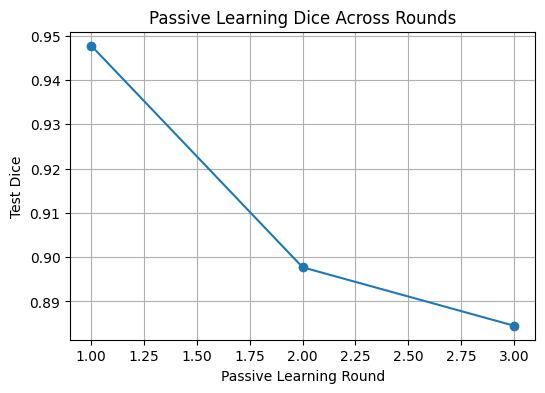

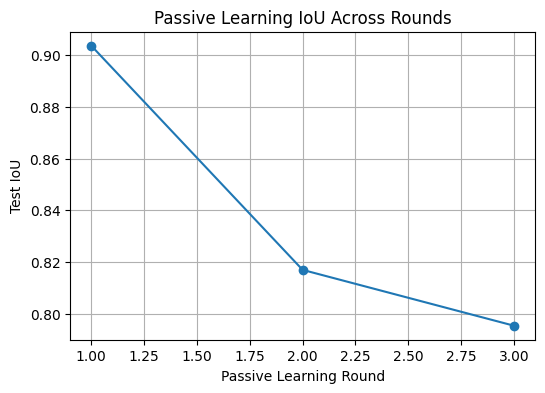

In [98]:
# %% =========================================================
# cell 23. visualize passive learning performance
# purpose:
# plot how segmentation performance changes across passive learning
# rounds on the full dataset
# ============================================================

if len(passive_history_df) > 0:
    plt.figure(figsize=(6, 4))
    plt.plot(passive_history_df["round"], passive_history_df["test_dice"], marker="o")
    plt.xlabel("Passive Learning Round")
    plt.ylabel("Test Dice")
    plt.title("Passive Learning Dice Across Rounds")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(passive_history_df["round"], passive_history_df["test_iou"], marker="o")
    plt.xlabel("Passive Learning Round")
    plt.ylabel("Test IoU")
    plt.title("Passive Learning IoU Across Rounds")
    plt.grid(True)
    plt.show()

In [99]:
# %% =========================================================
# cell 24. inspect final passive learning summary
# purpose:
# print a compact summary of the full passive learning experiment
# ============================================================

print("final labeled size:", len(passive_final_labeled_indices))
print("final unlabeled size:", len(passive_final_unlabeled_indices))

print("\npassive learning round summary:")
print(
    passive_history_df[
        [
            "round",
            "labeled_size",
            "unlabeled_size",
            "num_selected_this_round",
            "test_loss",
            "test_dice",
            "test_iou"
        ]
    ]
)

final labeled size: 50
final unlabeled size: 486

passive learning round summary:
   round  labeled_size  unlabeled_size  num_selected_this_round  test_loss  \
0      1            20             516                       10   0.743217   
1      2            30             506                       10   0.675787   
2      3            40             496                       10   0.628407   

   test_dice  test_iou  
0   0.947757  0.903509  
1   0.897714  0.817047  
2   0.884519  0.795514  


In [100]:
# %% =========================================================
# cell. visualize predicted masks
# purpose:
# show raw image, ground truth mask, and predicted mask side by side
# for a few examples from the dataset
# ============================================================

def visualize_predictions(model, dataset, device, num_examples=5, threshold=0.5):
    model.eval()

    if len(dataset) == 0:
        print("dataset is empty")
        return

    num_examples = min(num_examples, len(dataset))
    indices = np.random.choice(len(dataset), size=num_examples, replace=False)

    fig, axes = plt.subplots(num_examples, 3, figsize=(10, 4 * num_examples))

    if num_examples == 1:
        axes = np.expand_dims(axes, axis=0)

    with torch.no_grad():
        for row_idx, dataset_idx in enumerate(indices):
            sample = dataset[dataset_idx]

            image_tensor = sample["image"].unsqueeze(0).to(device)
            raw_image = sample["image"].squeeze().cpu().numpy()
            true_mask = sample["mask"].squeeze().cpu().numpy()

            logits = model(image_tensor)
            probs = torch.sigmoid(logits)
            pred_mask = (probs > threshold).float().squeeze().cpu().numpy()

            axes[row_idx, 0].imshow(raw_image, cmap="gray")
            axes[row_idx, 0].set_title(f"Raw Image\nindex={dataset_idx}")
            axes[row_idx, 0].axis("off")

            axes[row_idx, 1].imshow(true_mask, cmap="gray")
            axes[row_idx, 1].set_title("Ground Truth Mask")
            axes[row_idx, 1].axis("off")

            axes[row_idx, 2].imshow(pred_mask, cmap="gray")
            axes[row_idx, 2].set_title("Predicted Mask")
            axes[row_idx, 2].axis("off")

    plt.tight_layout()
    plt.show()

tifffile failed for raw image, trying PIL instead: <COMPRESSION.LZW: 5> requires the 'imagecodecs' package
tifffile failed for raw image, trying PIL instead: <COMPRESSION.LZW: 5> requires the 'imagecodecs' package
tifffile failed for raw image, trying PIL instead: <COMPRESSION.LZW: 5> requires the 'imagecodecs' package
tifffile failed for raw image, trying PIL instead: <COMPRESSION.LZW: 5> requires the 'imagecodecs' package
tifffile failed for raw image, trying PIL instead: <COMPRESSION.LZW: 5> requires the 'imagecodecs' package


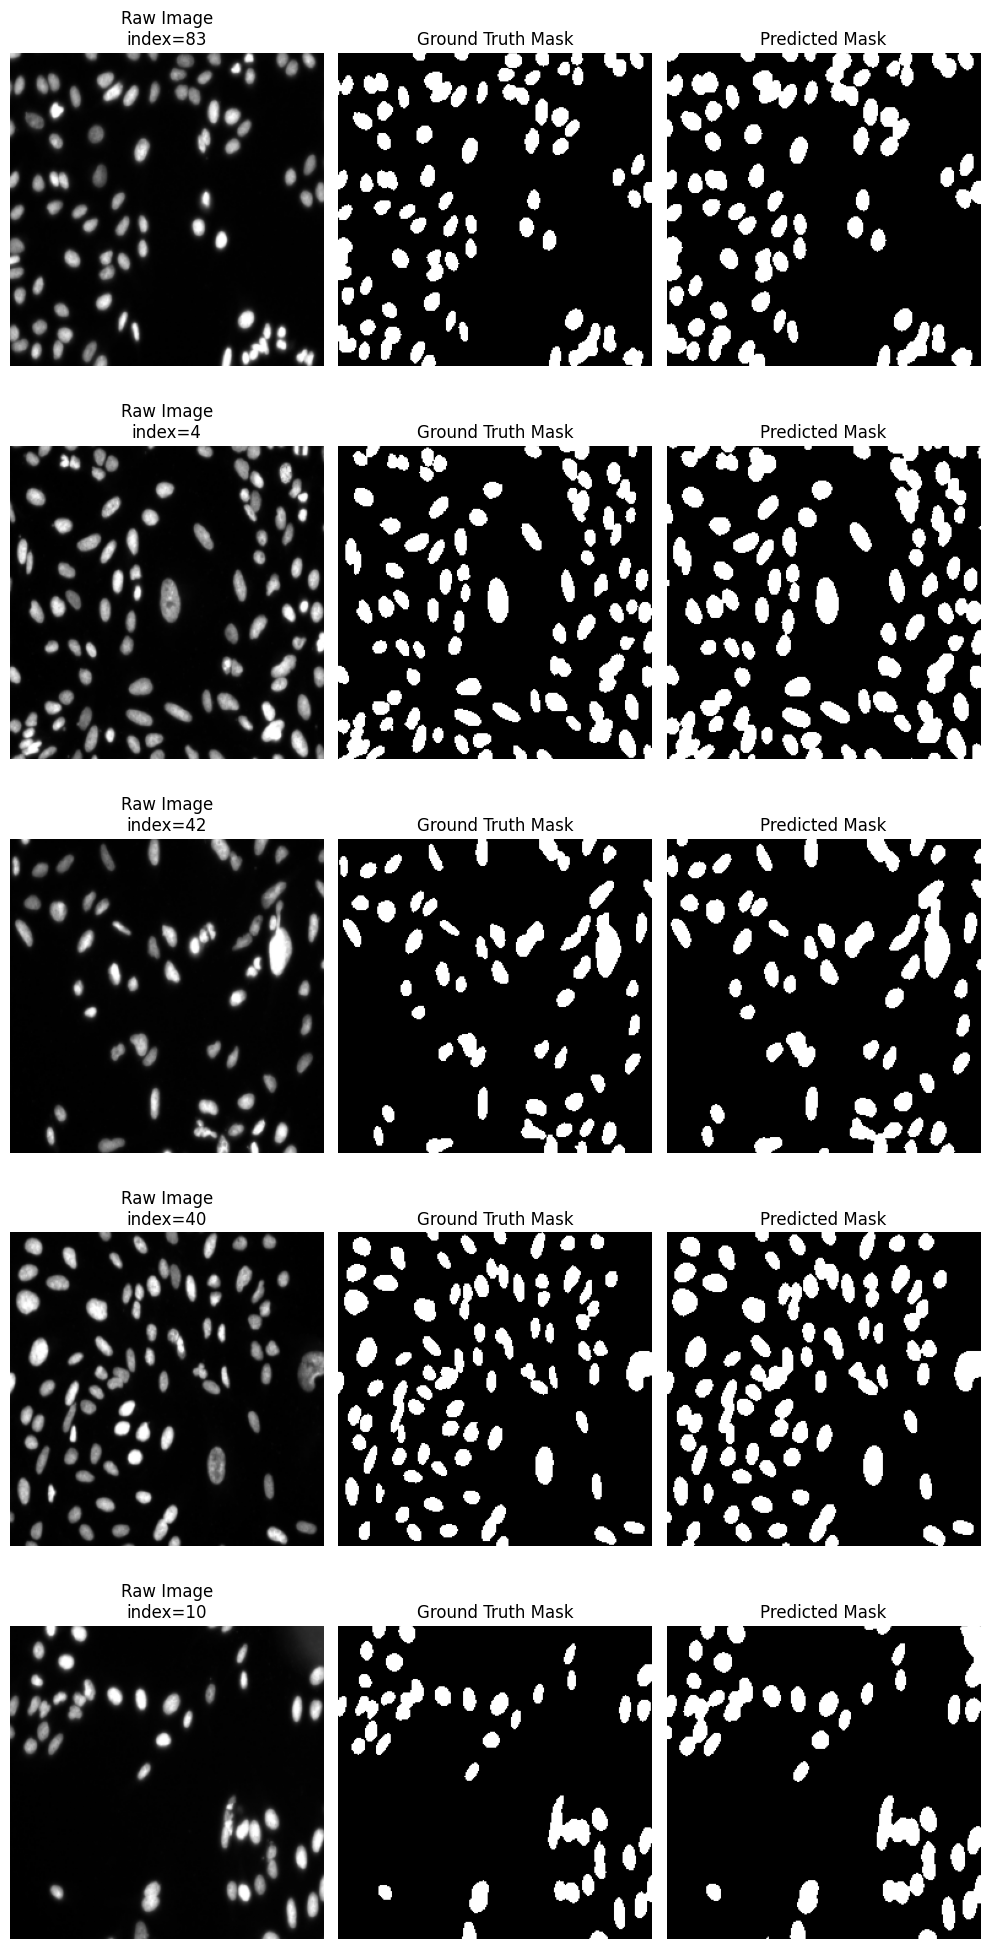

In [101]:
visualize_predictions(passive_model, test_dataset, DEVICE, num_examples=5, threshold=0.5)

tifffile failed for raw image, trying PIL instead: <COMPRESSION.LZW: 5> requires the 'imagecodecs' package
tifffile failed for raw image, trying PIL instead: <COMPRESSION.LZW: 5> requires the 'imagecodecs' package
tifffile failed for raw image, trying PIL instead: <COMPRESSION.LZW: 5> requires the 'imagecodecs' package
tifffile failed for raw image, trying PIL instead: <COMPRESSION.LZW: 5> requires the 'imagecodecs' package
tifffile failed for raw image, trying PIL instead: <COMPRESSION.LZW: 5> requires the 'imagecodecs' package


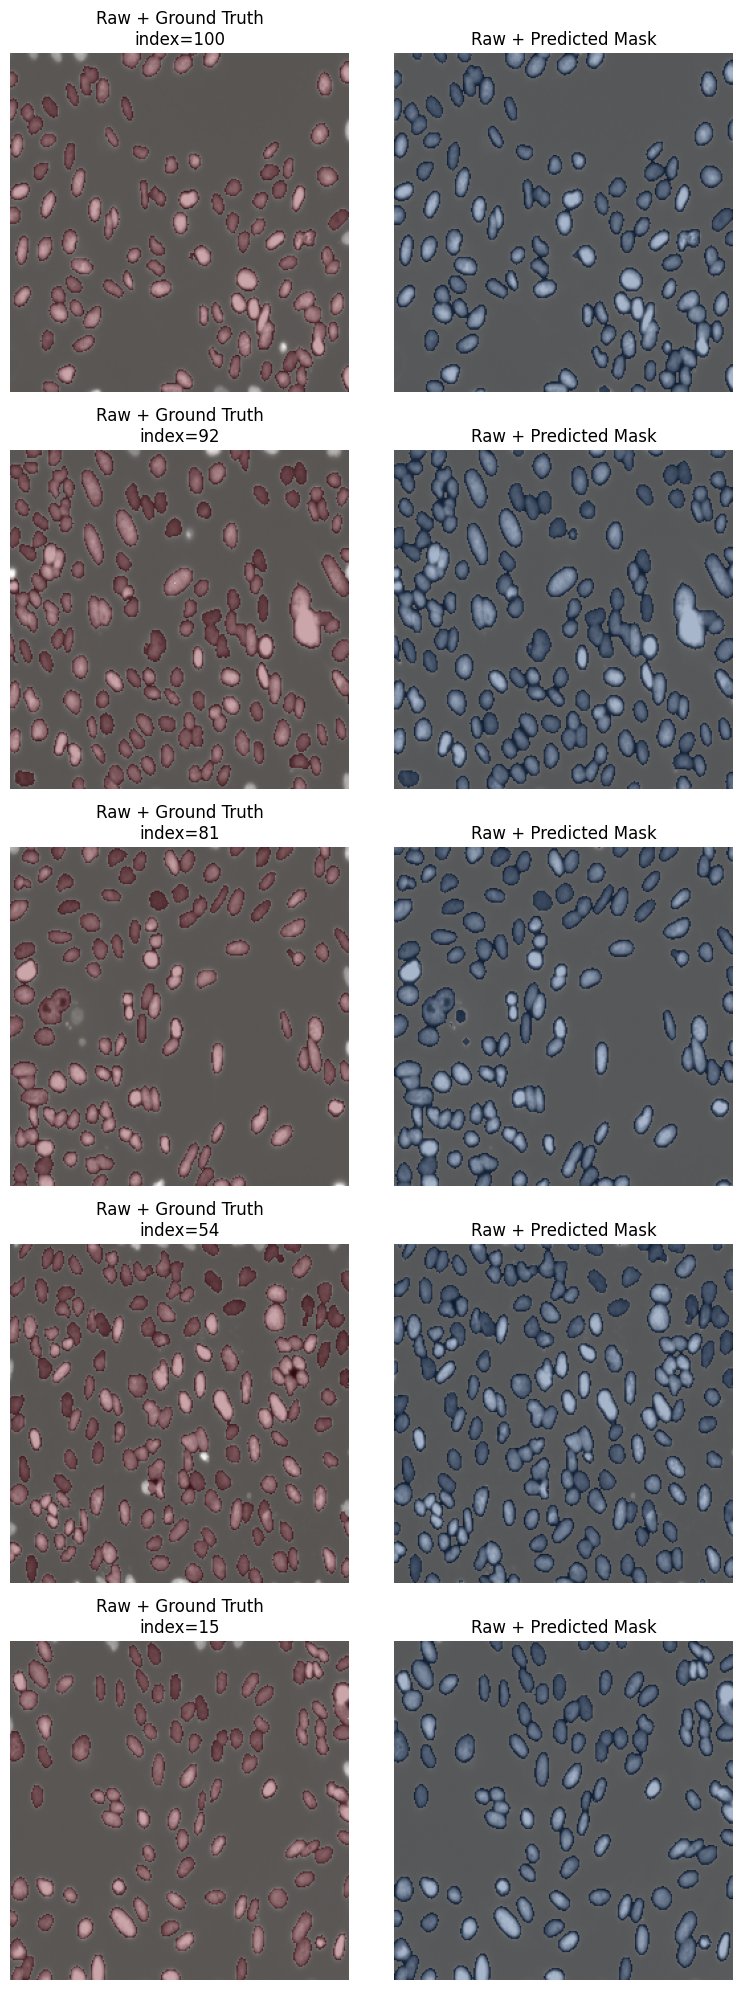

In [102]:
# %% =========================================================
# cell. visualize passive prediction overlays
# purpose:
# show raw image with true and predicted mask overlays
# ============================================================

def visualize_prediction_overlays(model, dataset, device, num_examples=3, threshold=0.5):
    model.eval()

    num_examples = min(num_examples, len(dataset))
    indices = np.random.choice(len(dataset), size=num_examples, replace=False)

    fig, axes = plt.subplots(num_examples, 2, figsize=(8, 4 * num_examples))

    if num_examples == 1:
        axes = np.expand_dims(axes, axis=0)

    with torch.no_grad():
        for row_idx, dataset_idx in enumerate(indices):
            sample = dataset[dataset_idx]

            image = sample["image"].unsqueeze(0).to(device)
            raw_image = sample["image"].squeeze().cpu().numpy()
            true_mask = sample["mask"].squeeze().cpu().numpy()

            logits = model(image)
            probs = torch.sigmoid(logits)
            pred_mask = (probs > threshold).float().squeeze().cpu().numpy()

            axes[row_idx, 0].imshow(raw_image, cmap="gray")
            axes[row_idx, 0].imshow(true_mask, cmap="Reds", alpha=0.35)
            axes[row_idx, 0].set_title(f"Raw + Ground Truth\nindex={dataset_idx}")
            axes[row_idx, 0].axis("off")

            axes[row_idx, 1].imshow(raw_image, cmap="gray")
            axes[row_idx, 1].imshow(pred_mask, cmap="Blues", alpha=0.35)
            axes[row_idx, 1].set_title("Raw + Predicted Mask")
            axes[row_idx, 1].axis("off")

    plt.tight_layout()
    plt.show()

visualize_prediction_overlays(passive_model, test_dataset, DEVICE, num_examples=5, threshold=0.5)


In [103]:
print("train size:", len(train_dataset))
print("val size:", len(val_dataset))
print("test size:", len(test_dataset))

train size: 536
val size: 116
test size: 116


In [104]:
# %% =========================================================
# cell. coarse grouping check
# purpose:
# see whether closely related image families appear across splits
# ============================================================

def coarse_group(image_id):
    parts = image_id.split("_")
    return "_".join(parts[:2]) if len(parts) >= 2 else image_id

train_groups = set(train_df["image_id"].map(coarse_group))
val_groups = set(val_df["image_id"].map(coarse_group))
test_groups = set(test_df["image_id"].map(coarse_group))

print("coarse train ∩ val:", len(train_groups & val_groups))
print("coarse train ∩ test:", len(train_groups & test_groups))
print("coarse val ∩ test:", len(val_groups & test_groups))

coarse train ∩ val: 0
coarse train ∩ test: 0
coarse val ∩ test: 0


In [105]:
torch.save(passive_model.state_dict(), "/content/drive/MyDrive/ASR_Project/passive_model_final.pt")
passive_history_df.to_csv("/content/drive/MyDrive/ASR_Project/passive_history.csv", index=False)